**1. Import Libraries**

In [154]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

**2. Mount Colab to Drive**

In [155]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**3. Import Dataset**

In [156]:
file_path = '/content/drive/MyDrive/Analisis/dataset_levelearn_heart.csv'

df_work = pd.read_csv(file_path, encoding='latin-1')

data = df_work
data.head(10)

,Timestamp,Email,Nama,NIM,Angkatan,Happiness_Q1,Happiness_Q2,Happiness_Q3,Happiness_Q4,Happiness_Q5,...,TaskSuccess_Q10,TaskSuccess_Q11,TaskSuccess_Q12,Qualitative_Q1,Qualitative_Q2,Qualitative_Q3,Qualitative_Q4,Feedback,Error,Suggestion
0,03/03/2026 13:23:48,christopasaribu90@gmail.com,Christo Pasaribu,11S23005,2023,5,5,5,5,5,...,4,4,4,"badge, saya terdorong untuk mengumpulkan lebih...",tidak,berguna semua,lebih terdorong setelah gamifikasi di terapkan,aplikasi sudah sangat bagus,tidak ada temuan error selama menggunakan apli...,ada hadiah yang lebih menarik
1,03/03/2026 13:24:39,samuelsibarani2510@gmail.com,Samuel faldhieto sibarani,11S23038,2023,5,5,5,5,5,...,5,5,5,Elemen dashboard karena membuat saya ingin men...,Tidak,Tidak,Menjadi lebih rajin karena belajar sambil berm...,Coba untuk menambahkan lagi fitur profile kara...,Tidak ada,Sudah baik
2,03/03/2026 13:24:58,christiaxxr@gmail.com,Christian Johannes Hutahaean,11S23036,2023,5,5,5,5,5,...,5,4,5,Leadboard,Tidak,Tidak ada,Sangat membantu dalam meningkatkan semangat be...,-,-,-
3,03/03/2026 13:24:59,ivanapasaribu17@gmail.com,Sri Intan Ivana Pasaribu,11S23006,2023,4,4,4,4,4,...,4,4,4,streak karena menantang,tidak,tidak,sesudah membjat lebih belajar karena ada metod...,sudah sangat baik,bagian essay jawabannya harus sama oersis biar...,jawaban essay tolong dikembangkan ya kak/bang
4,03/03/2026 13:25:00,joey.cristo05@gmail.com,Joey Cristo Thruli,11S23012,2023,5,5,5,5,5,...,5,5,5,Streak,Tidak,Menurut saya semuanya berguna dan bermanfaat. ...,"Karena gamifikasi yang diterapkan, saya merasa...","Aplikasi sudah bagus, penggunaan warna juga sa...",tidak ada,menurut saya elemen gamifikasinya dapat diting...
5,03/03/2026 13:25:41,danieltbg145@gmail.com,Daniel L. Tobing,11S23025,2023,4,4,4,5,5,...,5,5,5,Adanya sistwm rank,Tidak,"Ada, fitur ranknya jadi siapa yang cepat menja...",Lebih menarik dan tertantang,Aplikasi menarik dan menantang mahasiswa untuk...,Tidak ada untuk saat ini,Adanya fitur siapa paling cepat mejawab oertan...
6,03/03/2026 13:25:42,andresaragih932@gmail.com,Andre Christian Saragih,11S23026,2023,4,5,4,5,4,...,5,5,5,elemen leaderboard jadi memotifasi saya dalam ...,"Sudah baik, tidak usah",Semua Baik,Menjadi lebih mudah memahami,Sudah baik,sejauh ini baik,sudah baik
7,03/03/2026 13:26:02,marshallmanurung92@gmail.com,MARSHALL MANURUNG,11S23021,2023,4,4,5,4,4,...,5,4,5,Materi lebih ringkas(to the point) jadi lebih ...,Tidak,ga ada,sebelum menggunakan gamifikasi pembelajaran su...,Sangat bagus dan menarik untuk digunakan jangk...,"Mungkin lebih ke jawaban essay,, (karena essay...",Mungkin bisa dibuat kembali ke soal sebelumnya...
8,03/03/2026 13:26:17,gloriapanjaitan3012@gmail.com,Gloria Panjaitan,11S23030,2023,5,5,5,5,5,...,5,4,4,Poin karena seolah punya uang,Tidak,Tidak,Lebih seru dengan gamifikasi,"Bagus, silahkan ditingkatkan kak bang",Temuan bug saya pada aplikasi yaitu progres ba...,Butuh suara yang unik untuk aksi misalnya meny...
9,03/03/2026 13:26:24,yuripakpahan2205@gmail.com,Yuri Pakpahan,11S23051,2023,4,4,4,4,4,...,4,4,4,"Ranking, karena memberi rasa kompetitif",Tidak,Tidak,Saya lebih senang menggunakan aplikasi belajar...,Sudah bagus,Tidak ada,Sudah baik


**4. Data Pre-Processing**

**4.1 CEK DAN TANGANI DUPLIKASI DATA**

In [157]:
metrics = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
likert_columns = [f"{metric}_Q{i}" for metric in metrics for i in range(1, 13)]

print(f"Jumlah baris sebelum hapus duplikat: {data.shape[0]}")
data = data.drop_duplicates(subset=['NIM'], keep='last').copy()
print(f"Jumlah baris setelah hapus duplikat: {data.shape[0]}\n")

df_likert = data[likert_columns].astype(float)
df_likert["Total_Score"] = df_likert.sum(axis=1)

Jumlah baris sebelum hapus duplikat: 54
Jumlah baris setelah hapus duplikat: 54



**4.2 CEK DAN TANGANI MISSING VALUES (NaN)**

In [158]:
missing_values = df_likert.isnull().sum().sum()
print(f"Total missing values di kolom Likert: {missing_values}")

if missing_values > 0:
    # Menghapus baris yang memiliki nilai kosong
    df_likert = df_likert.dropna()
    # Menyesuaikan kembali data utama agar jumlah barisnya sama
    data = data.loc[df_likert.index]
    print("Baris dengan missing values telah dihapus.\n")
else:
    print("Tidak ada missing values yang ditemukan.\n")

Total missing values di kolom Likert: 0
Tidak ada missing values yang ditemukan.



**4.3 DETEKSI OUTLIER (STRAIGHT-LINING)**

In [159]:
df_likert['Std_Dev'] = df_likert[likert_columns].std(axis=1)
straight_liners = df_likert[df_likert['Std_Dev'] == 0]
print(f"Jumlah responden terindikasi straight-lining (nilai konstan): {len(straight_liners)}\n")

Jumlah responden terindikasi straight-lining (nilai konstan): 5



**4.4 FEATURE ENGINEERING: SKOR PER DIMENSI HEART**

In [160]:
df_likert['Happiness_Avg'] = df_likert[[col for col in likert_columns if 'Happiness' in col]].mean(axis=1)
df_likert['Engagement_Avg'] = df_likert[[col for col in likert_columns if 'Engagement' in col]].mean(axis=1)
df_likert['Adoption_Avg'] = df_likert[[col for col in likert_columns if 'Adoption' in col]].mean(axis=1)
df_likert['Retention_Avg'] = df_likert[[col for col in likert_columns if 'Retention' in col]].mean(axis=1)
df_likert['TaskSuccess_Avg'] = df_likert[[col for col in likert_columns if 'TaskSuccess' in col]].mean(axis=1)

df_final = pd.concat([data[['Nama', 'NIM']], df_likert], axis=1)

df_final.head()

,Nama,NIM,Happiness_Q1,Happiness_Q2,Happiness_Q3,Happiness_Q4,Happiness_Q5,Happiness_Q6,Happiness_Q7,Happiness_Q8,...,TaskSuccess_Q10,TaskSuccess_Q11,TaskSuccess_Q12,Total_Score,Std_Dev,Happiness_Avg,Engagement_Avg,Adoption_Avg,Retention_Avg,TaskSuccess_Avg
0,Christo Pasaribu,11S23005,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,4.0,4.0,4.0,294.0,0.302532,5.0,5.0,5.0,5.000000,4.500000
1,Samuel faldhieto sibarani,11S23038,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,5.0,5.0,300.0,0.000000,5.0,5.0,5.0,5.000000,5.000000
2,Christian Johannes Hutahaean,11S23036,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,4.0,5.0,293.0,0.323732,5.0,5.0,5.0,5.000000,4.416667
3,Sri Intan Ivana Pasaribu,11S23006,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,4.0,4.0,4.0,249.0,0.360085,4.0,4.0,4.0,4.416667,4.333333
4,Joey Cristo Thruli,11S23012,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,5.0,5.0,300.0,0.000000,5.0,5.0,5.0,5.000000,5.000000


**4.5 VISUALISASI**

In [161]:
dimensi_avg_cols = ['Happiness_Avg', 'Engagement_Avg', 'Adoption_Avg', 'Retention_Avg', 'TaskSuccess_Avg']
dimensi_labels = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']

sns.set_theme(style="whitegrid")

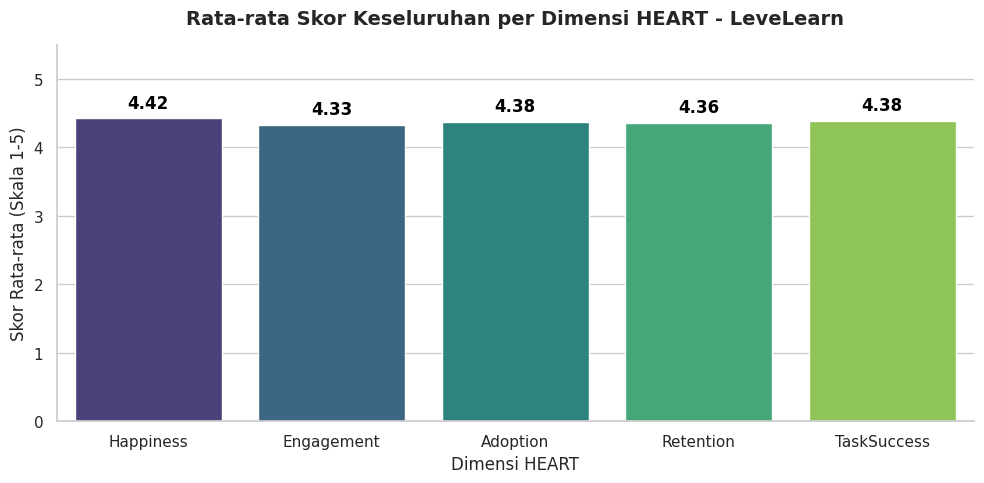

In [162]:
plt.figure(figsize=(10, 5))

# Menghitung rata-rata dari kolom yang sudah didefinisikan di atas
rata_rata_keseluruhan = df_final[dimensi_avg_cols].mean()

ax = sns.barplot(x=dimensi_labels, y=rata_rata_keseluruhan.values, palette="viridis")
plt.ylim(0, 5.5) # Asumsi skala Likert 1-5
plt.title("Rata-rata Skor Keseluruhan per Dimensi HEART - LeveLearn", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Skor Rata-rata (Skala 1-5)", fontsize=12)
plt.xlabel("Dimensi HEART", fontsize=12)

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

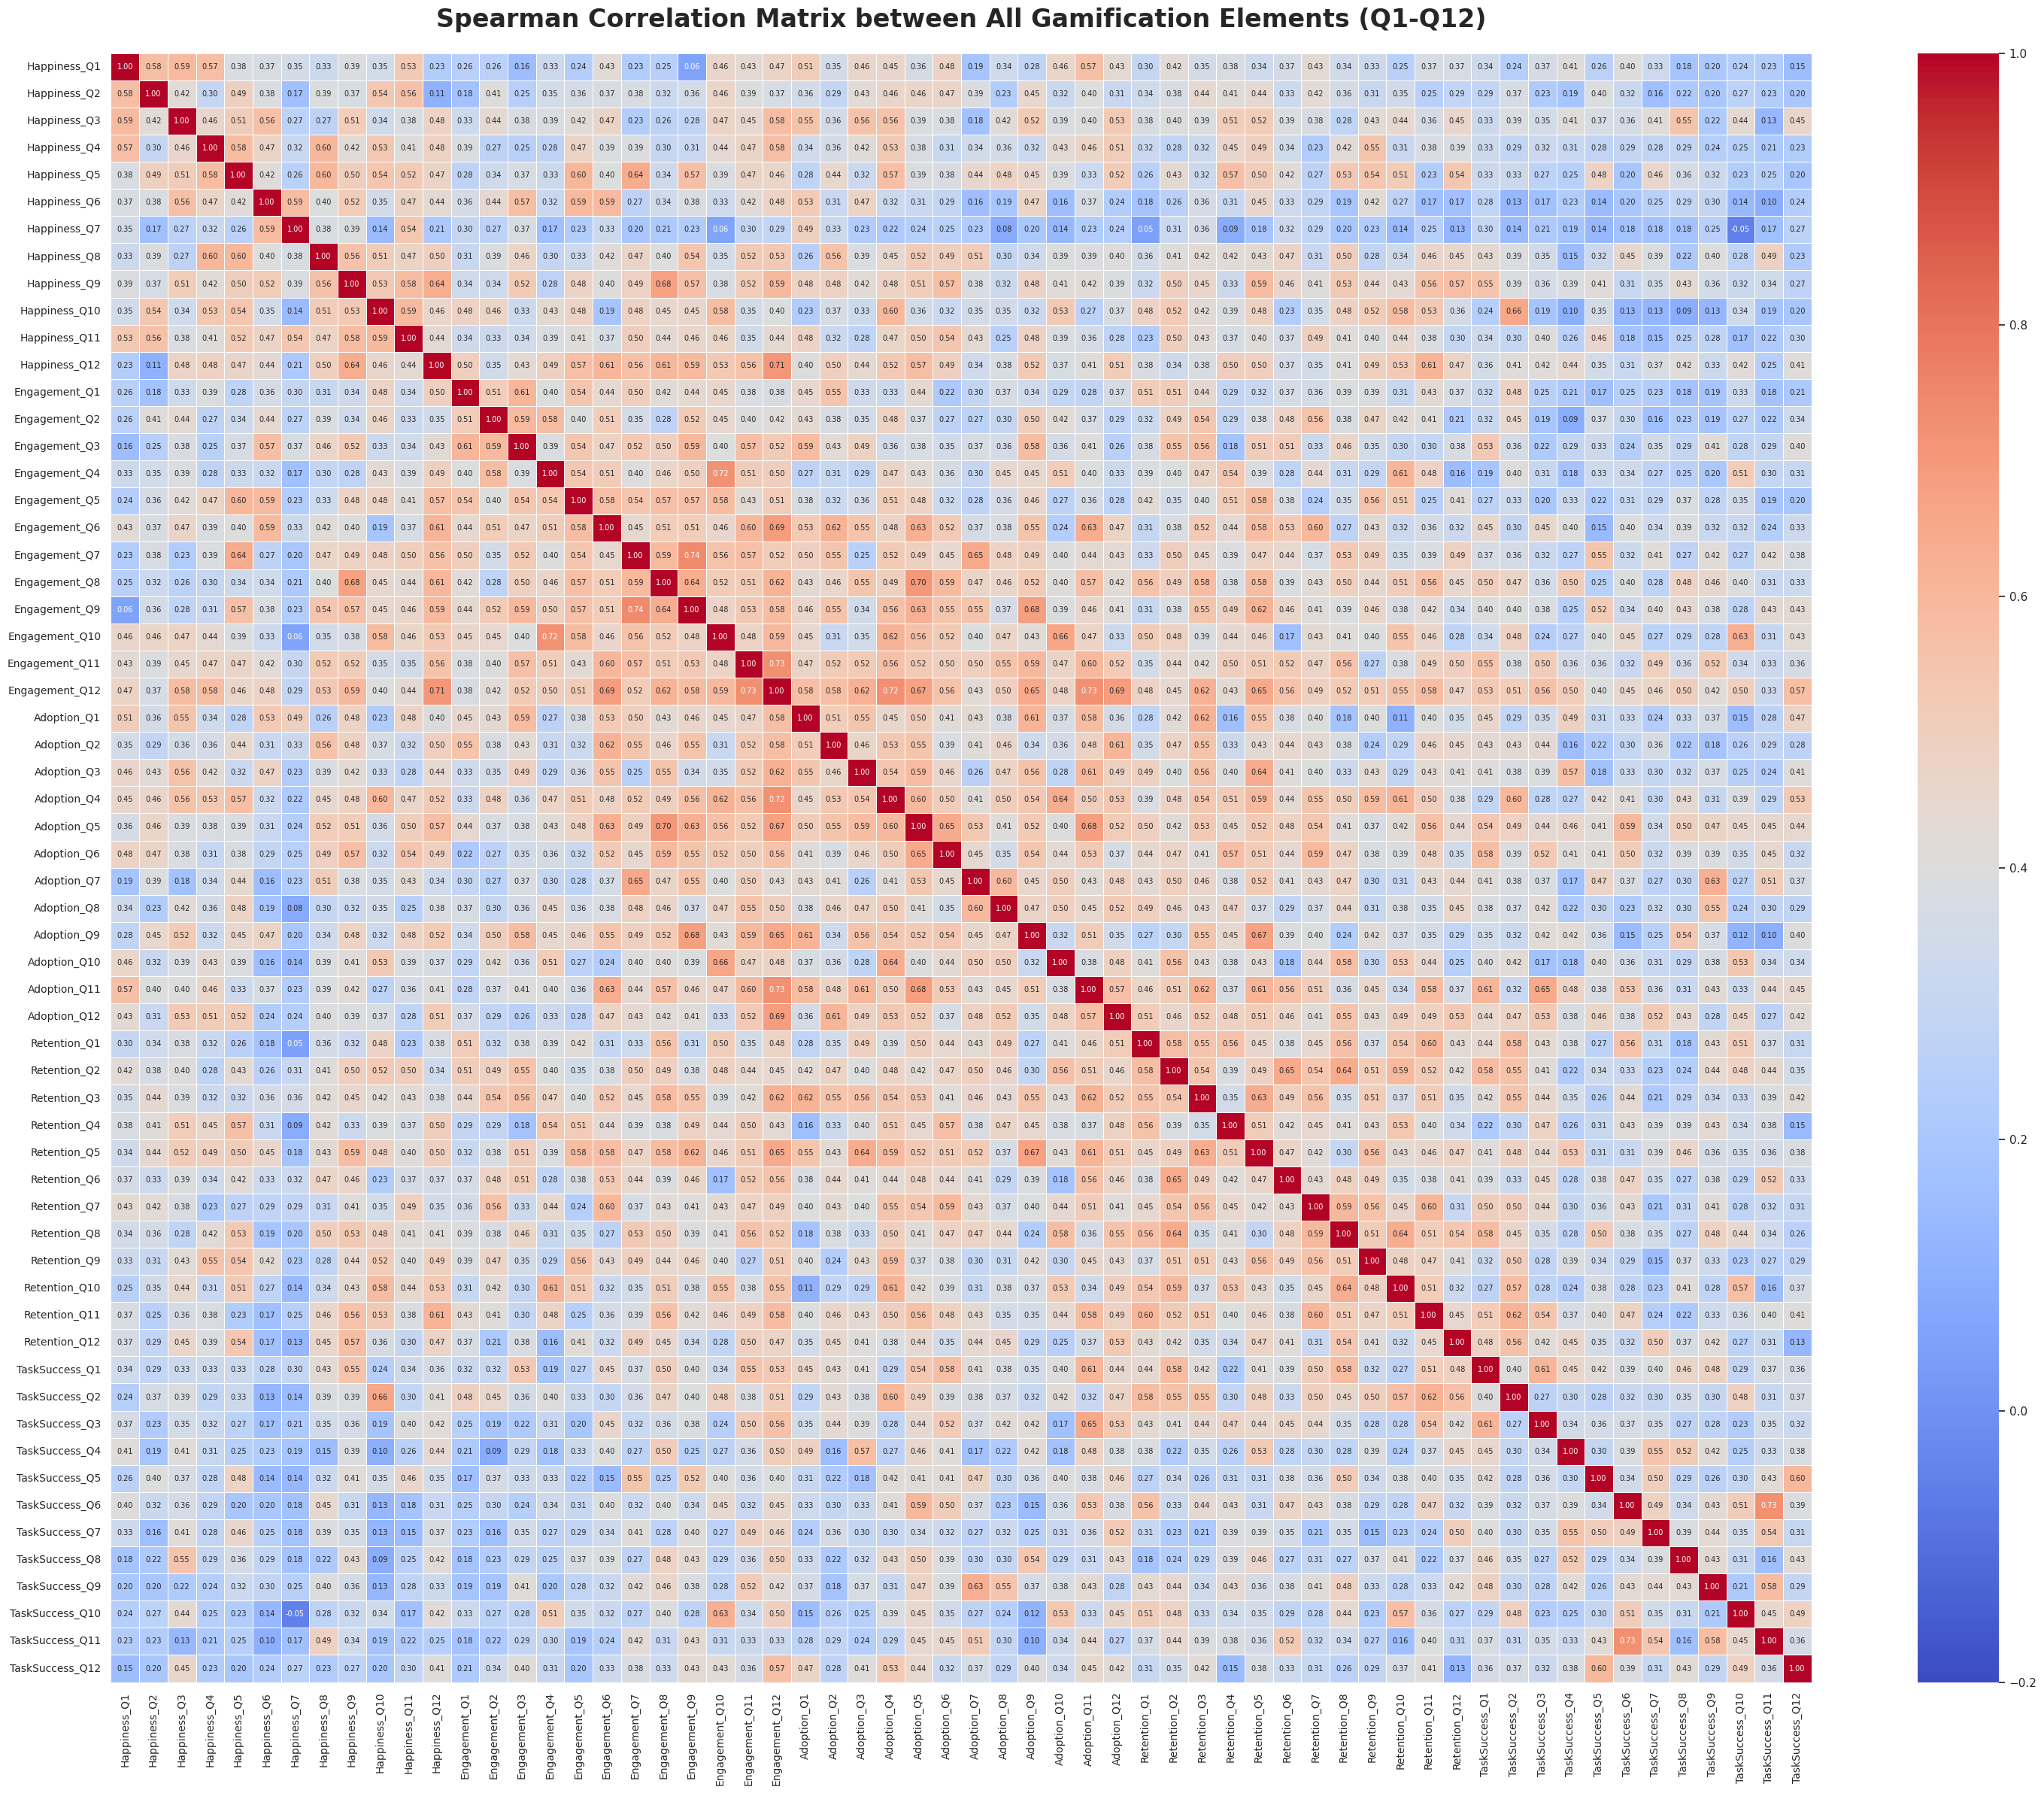

In [163]:
metrics = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
all_columns = [f"{metric}_Q{i}" for metric in metrics for i in range(1, 13)]

# Menghitung korelasi untuk seluruh 60 pertanyaan
corr_matrix_all = df_likert[all_columns].corr(method='spearman')

plt.figure(figsize=(30, 24))

sns.heatmap(corr_matrix_all,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-0.2, vmax=1.0,
            linewidths=0.5,
            annot_kws={"size": 7},
            xticklabels=all_columns,
            yticklabels=all_columns)

plt.title('Spearman Correlation Matrix between All Gamification Elements (Q1-Q12)', fontsize=24, fontweight='bold', pad=25)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [164]:
df_pre = data.drop_duplicates(subset=['NIM'], keep='last').copy()
df_pre['NIM'] = df_pre['NIM'].astype(str).str.strip()

nims_to_remove = [
    '11S23053', '11S23045', '11S23023', '11S23040', '11S23010',
    '11S23004', '11S23007', '11S23011', '11S23016', '11S23042',
    '11S23017', '11S23035', '11S23036', '11S23020', '11S23005',
    '11S23048', '11S23041', '11S23013'
]

df_work = df_pre[~df_pre['NIM'].isin(nims_to_remove)].copy()

print(f"Pembersihan Selesai.")
print(f"Jumlah Data Dihapus : {len(nims_to_remove)} responden")
print(f"Jumlah Data Bersih  : {len(df_work)} responden (Variabel 'df_work' siap digunakan)")

Pembersihan Selesai.
Jumlah Data Dihapus : 18 responden
Jumlah Data Bersih  : 36 responden (Variabel 'df_work' siap digunakan)


**5.  Define Variables and Standarization of Variable X**

In [179]:
metrics = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
gamification_columns = [f"{metric}_Q{i}" for metric in metrics for i in range(1, 13)]

for metric in metrics:
    cols = [f"{metric}_Q{i}" for i in range(1, 13)]
    df_work[metric] = df_work[cols].mean(axis=1)

X = df_work[gamification_columns]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**6. Uji Multikolinearitas (VIF)**

In [180]:
def calculate_regularized_vif(X_scaled_data, columns, alpha=0.01):
    df_temp = pd.DataFrame(X_scaled_data, columns=columns)

    corr_matrix = df_temp.corr().values

    reg_corr_matrix = corr_matrix + np.eye(corr_matrix.shape[0]) * alpha

    inv_corr = np.linalg.inv(reg_corr_matrix)

    vif_values = np.diagonal(inv_corr)

    return pd.DataFrame({
        "Variable": columns,
        "VIF_Adjusted": vif_values
    })

vif_df = calculate_regularized_vif(X_scaled, gamification_columns, alpha=0.01)

print("==== HASIL VIF DENGAN PENYESUAIAN (REGULARIZED) ====")
print("Nilai ini menunjukkan tingkat kolinearitas relatif antar variabel.")
print(vif_df.sort_values(by="VIF_Adjusted", ascending=False).to_string())

==== HASIL VIF DENGAN PENYESUAIAN (REGULARIZED) ====
Nilai ini menunjukkan tingkat kolinearitas relatif antar variabel.
           Variable  VIF_Adjusted
23   Engagement_Q12     70.618973
20    Engagement_Q9     66.577739
28      Adoption_Q5     66.217949
40     Retention_Q5     65.138122
33     Adoption_Q10     63.147238
21   Engagement_Q10     63.014694
34     Adoption_Q11     62.720429
46    Retention_Q11     61.073185
9     Happiness_Q10     60.321407
45    Retention_Q10     60.028722
2      Happiness_Q3     58.495144
4      Happiness_Q5     57.323720
39     Retention_Q4     57.027806
58  TaskSuccess_Q11     56.243818
19    Engagement_Q8     55.921577
30      Adoption_Q7     55.698929
52   TaskSuccess_Q5     55.174960
17    Engagement_Q6     54.819250
26      Adoption_Q3     54.587120
32      Adoption_Q9     53.517453
5      Happiness_Q6     53.371068
27      Adoption_Q4     52.964874
16    Engagement_Q5     52.875551
8      Happiness_Q9     52.857264
37     Retention_Q2     52.619

**7. Eksekusi Ridge Regression & Evaluasi**

In [184]:
#Ridge Regression untuk Regularisasi: Menggunakan alpha=1.0 sebagai nilai awal untuk menekan koefisien variabel yang berkorelasi tinggi
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

#Prediksi dengan data testing
y_pred_ridge = ridge_model.predict(X_test)

# Evaluasi model Ridge: Menghitung seberapa baik model menjelaskan varians data (R2) dan tingkat kesalahan (MSE)
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("\n==== HASIL REGRESI RIDGE ====")
print(f"R² pada data test: {r2_ridge:.4f}")
print(f"Mean Squared Error: {mse_ridge:.5f}")


==== HASIL REGRESI RIDGE ====
R² pada data test: 0.9546
Mean Squared Error: 0.01040


**8. Visualisasi Koefisien (Bar Chart & Heatmap)**

In [190]:
coef_df = pd.DataFrame(ridge_model.coef_.T, index=gamification_columns, columns=dependent_variables)

print("\n==== HASIL LENGKAP KOEFISIEN RIDGE (60 ELEMEN) ====")
print(coef_df.to_string())



==== HASIL LENGKAP KOEFISIEN RIDGE (60 ELEMEN) ====
                 Happiness  Engagement  Adoption  Retention  TaskSuccess
Happiness_Q1      0.043181   -0.017094  0.006126   0.007939     0.001145
Happiness_Q2      0.035267    0.001345  0.015604  -0.004446    -0.007327
Happiness_Q3      0.016427   -0.005492  0.020197   0.004512     0.020094
Happiness_Q4      0.027344    0.016985 -0.000507   0.000602     0.006817
Happiness_Q5      0.014902   -0.005418  0.027283   0.000893     0.012393
Happiness_Q6      0.037084    0.021632 -0.001297  -0.015015     0.000413
Happiness_Q7      0.032236    0.009729  0.001426   0.005666    -0.018049
Happiness_Q8      0.015191    0.009818  0.011694  -0.001240     0.012697
Happiness_Q9      0.031437    0.001761  0.008983   0.030833    -0.009690
Happiness_Q10     0.027447    0.008903  0.014071   0.010862     0.003264
Happiness_Q11     0.022407    0.011703  0.012623  -0.007007     0.011863
Happiness_Q12     0.011738    0.021606  0.031996   0.006501    -0.00837

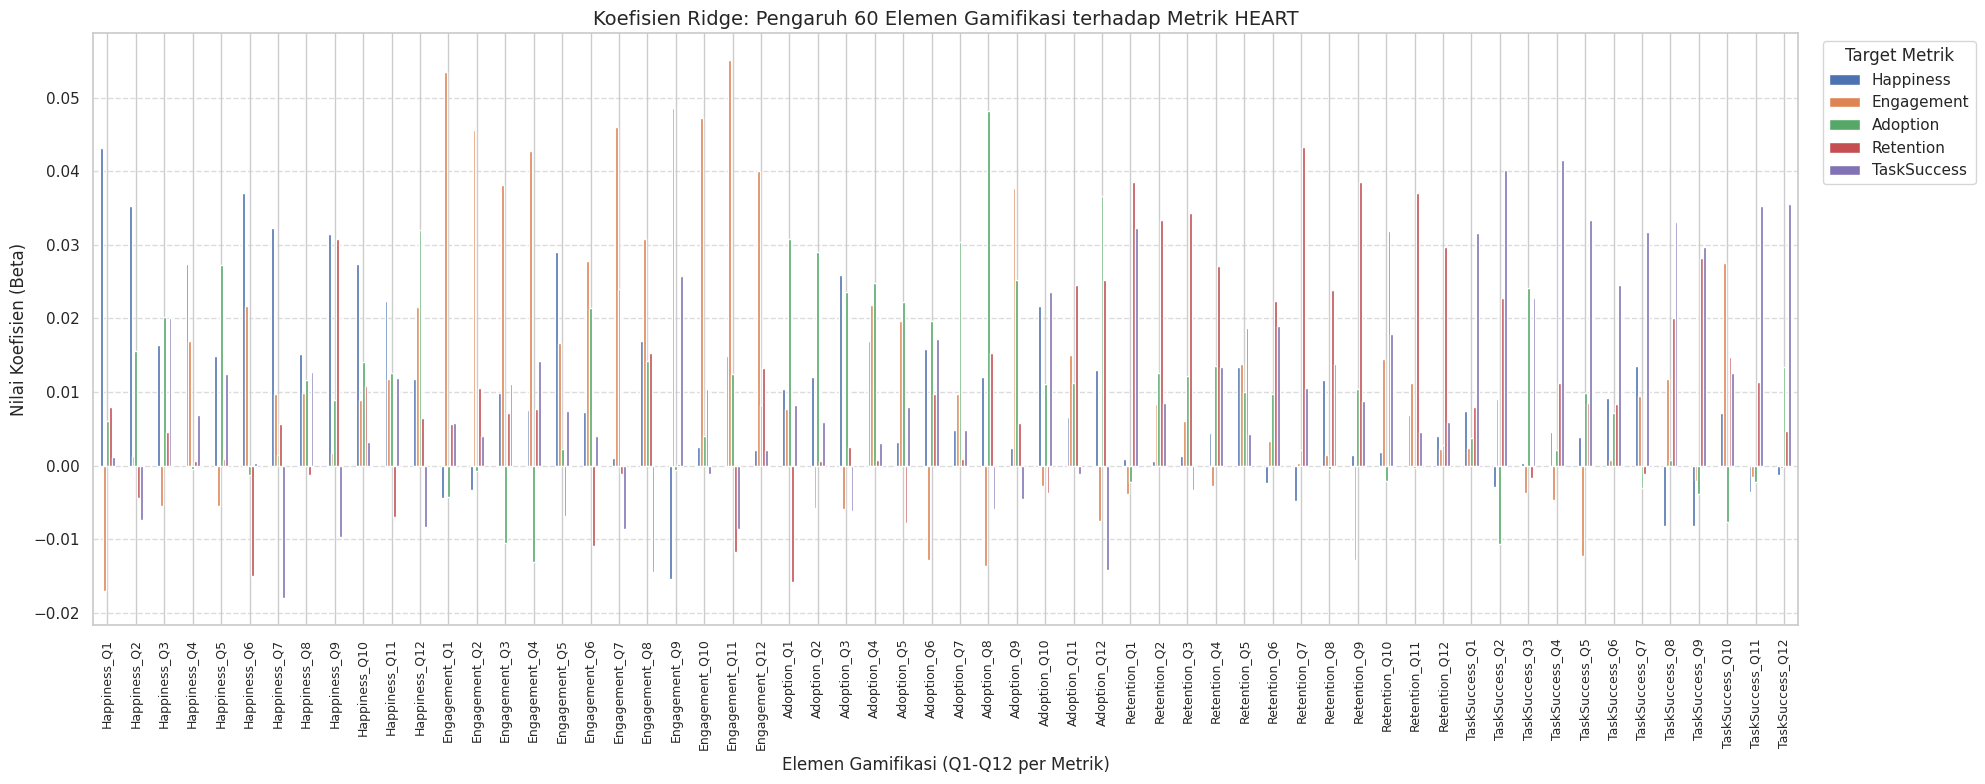

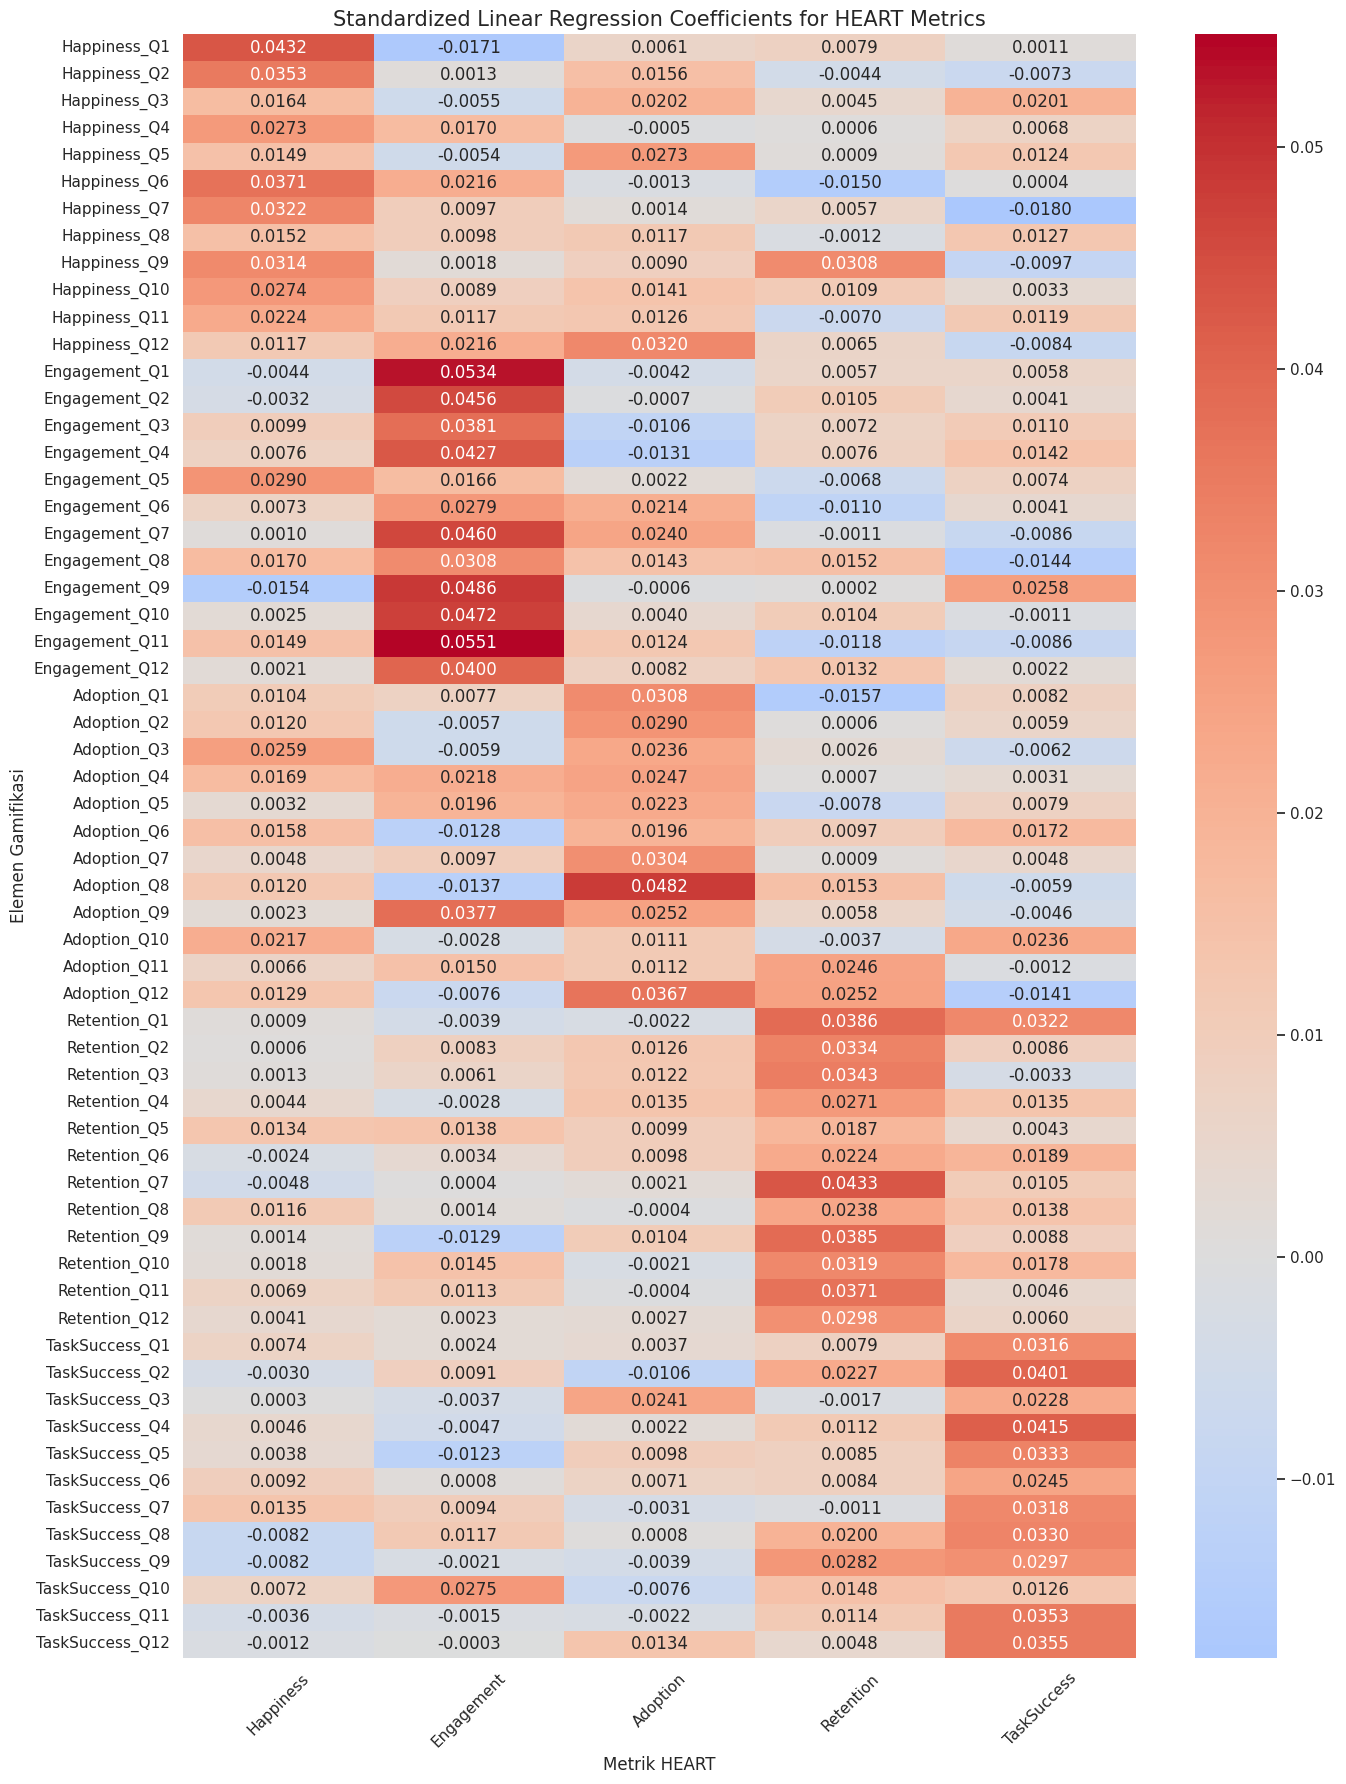

In [191]:
coef_df.plot(kind='bar', figsize=(20, 8), legend=True)
plt.title("Koefisien Ridge: Pengaruh 60 Elemen Gamifikasi terhadap Metrik HEART", fontsize=14)
plt.ylabel("Nilai Koefisien (Beta)")
plt.xlabel("Elemen Gamifikasi (Q1-Q12 per Metrik)")
plt.xticks(fontsize=9, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Target Metrik", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 18))
sns.heatmap(coef_df, annot=True, fmt=".4f", cmap="coolwarm", center=0)
plt.title("Standardized Linear Regression Coefficients for HEART Metrics", fontsize=15)
plt.ylabel("Elemen Gamifikasi")
plt.xlabel("Metrik HEART")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**9. Sel: Regresi Linear Berganda (OLS Summary) per Metrik HEART**

In [193]:
for aspect in dependent_variables:
    y = df_work[aspect]

    X_with_const = sm.add_constant(X_scaled)

    model = sm.OLS(y, X_with_const).fit()

    print(f"\n" + "="*80)
    print(f"==== HASIL REGRESI LINEAR BERGANDA [{aspect.upper()}] ====")
    print("="*80)
    print(model.summary())


==== HASIL REGRESI LINEAR BERGANDA [HAPPINESS] ====
                            OLS Regression Results                            
Dep. Variable:              Happiness   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.321e+26
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           4.00e-40
Time:                        14:54:15   Log-Likelihood:                 1116.7
No. Observations:                  36   AIC:                            -2167.
Df Residuals:                       3   BIC:                            -2115.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------